In [1]:
import pandas as pd
import os
os.chdir('../')
os.getcwd()

'd:\\GitHub\\appliance_energy_prediction'

In [20]:
from src.components.network import LSTMRegression, CNNLSTMRegression
from src.components.dataset import get_loaders_from_dataframe

In [8]:
df = pd.read_csv("data\\processed\\preprocessed_data.csv")

In [9]:
df.columns

Index(['date', 'Appliances_capped_lag1', 'Appliances_capped_rollmean3h',
       'hour', 'rv1', 'Press_mm_hg', 'RH_5', 'Appliances_capped_lag3', 'T8',
       'T6', 'T2', 'RH_out', 'RH_9', 'RH_2', 'Visibility', 'Tdewpoint', 'RH_8',
       'T4', 'T1_x_RH_1', 'Windspeed', 'RH_1', 'Appliances_capped'],
      dtype='object')

In [10]:
train_loader, val_loader, x_scaler, y_scaler = get_loaders_from_dataframe(
        df,
        target_col="Appliances_capped",
        seq_len=33,
        batch_size=128,
        val_size=0.2
    )

Columns: Index(['Appliances_capped_lag1', 'Appliances_capped_rollmean3h', 'hour', 'rv1',
       'Press_mm_hg', 'RH_5', 'Appliances_capped_lag3', 'T8', 'T6', 'T2',
       'RH_out', 'RH_9', 'RH_2', 'Visibility', 'Tdewpoint', 'RH_8', 'T4',
       'T1_x_RH_1', 'Windspeed', 'RH_1', 'Appliances_capped'],
      dtype='object')
Target col used: Appliances_capped
Train size: 15748, Val size: 3937


In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_predictions(model, test_loader, y_scaler=None, device='cuda'):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(x_batch)
            preds.append(outputs.cpu().numpy())
            targets.append(y_batch.cpu().numpy())
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    if y_scaler is not None:
        preds = y_scaler.inverse_transform(preds)
        targets = y_scaler.inverse_transform(targets)
    return preds, targets


In [18]:
def plot_predictions(y_true, y_pred, n=300, model=None):
    plt.figure(figsize=(14, 5))
    plt.plot(y_true[:n], label='Real', linewidth=2)
    plt.plot(y_pred[:n], label=f'{model}', linewidth=2)
    plt.title('Real vs Predicted (First {} Samples)'.format(n))
    plt.xlabel('Sample')
    plt.ylabel('Target Value')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [21]:
hidden_dim = 89
num_layers = 2
dropout = 0.07132012331706888
seq_len = 33    # used for DataLoader creation, not the model directly
batch_size = 128  # used for DataLoader creation, not the model directly

model = CNNLSTMRegression(input_dim=20, cnn_out_channels=39, kernel_size=4, 
                                  lstm_hidden_dim=63, lstm_num_layers=3, output_dim=1,
                                    dropout=0.460)


In [22]:
import torch

checkpoint_path = "artifacts\\best_CNN-LSTM Regression_model_trial_0_rmse23.8916.pt"
model.load_state_dict(torch.load(checkpoint_path, map_location='cuda'))  # or 'cpu' if needed
model.eval()
model.to('cuda')

RuntimeError: Error(s) in loading state_dict for CNNLSTMRegression:
	Missing key(s) in state_dict: "lstm.weight_ih_l1", "lstm.weight_hh_l1", "lstm.bias_ih_l1", "lstm.bias_hh_l1", "lstm.weight_ih_l2", "lstm.weight_hh_l2", "lstm.bias_ih_l2", "lstm.bias_hh_l2". 

In [16]:
import joblib
y_scaler = joblib.load("y_scaler_trial.pkl")

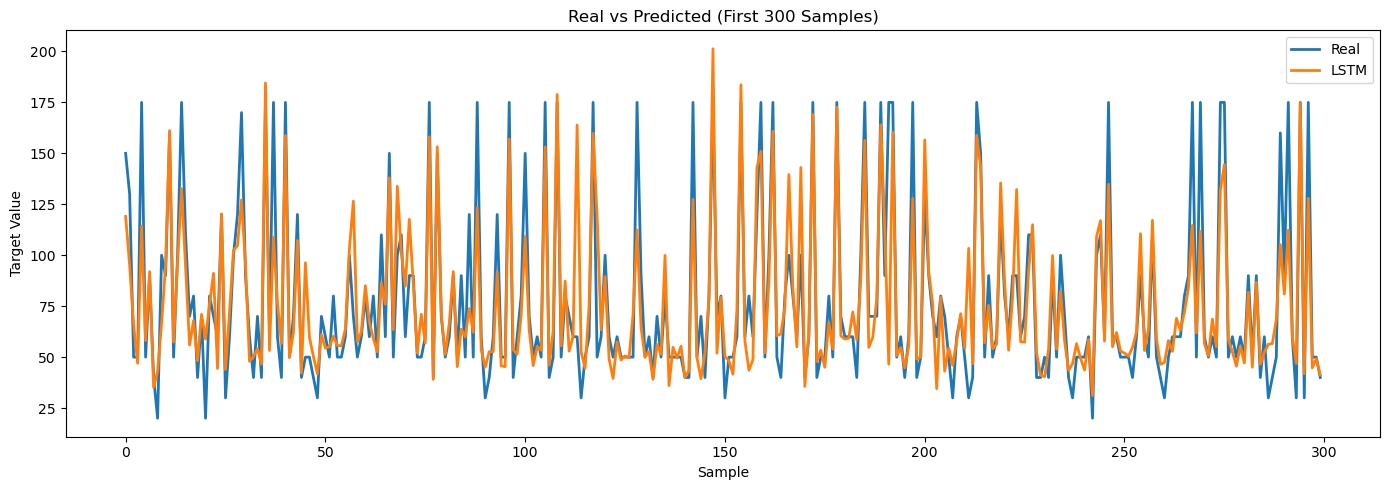

In [19]:
# Get predictions and ground-truths
y_pred, y_true = get_predictions(model, val_loader, y_scaler=y_scaler, device='cuda')

# Plot
plot_predictions(y_true, y_pred, n=300, model="LSTM")  # Change n if you want a different range
